Device: cpu
Época [1/10] | loss=0.3759 | cls(MSE)=0.0614 | recon(BCE)=0.3145 | acc=50.32%
Época [2/10] | loss=0.2211 | cls(MSE)=0.0188 | recon(BCE)=0.2023 | acc=87.60%
Época [3/10] | loss=0.1921 | cls(MSE)=0.0152 | recon(BCE)=0.1768 | acc=89.94%
Época [4/10] | loss=0.1777 | cls(MSE)=0.0135 | recon(BCE)=0.1642 | acc=91.13%
Época [5/10] | loss=0.1676 | cls(MSE)=0.0122 | recon(BCE)=0.1554 | acc=92.07%
Época [6/10] | loss=0.1601 | cls(MSE)=0.0112 | recon(BCE)=0.1489 | acc=92.72%
Época [7/10] | loss=0.1540 | cls(MSE)=0.0103 | recon(BCE)=0.1437 | acc=93.38%
Época [8/10] | loss=0.1489 | cls(MSE)=0.0097 | recon(BCE)=0.1392 | acc=93.77%
Época [9/10] | loss=0.1450 | cls(MSE)=0.0092 | recon(BCE)=0.1358 | acc=94.11%
Época [10/10] | loss=0.1416 | cls(MSE)=0.0087 | recon(BCE)=0.1329 | acc=94.50%


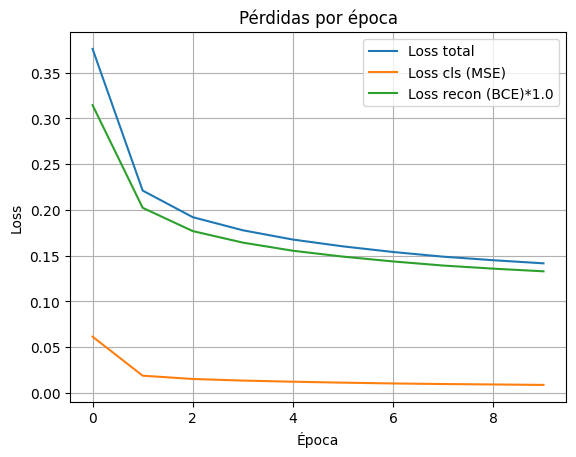

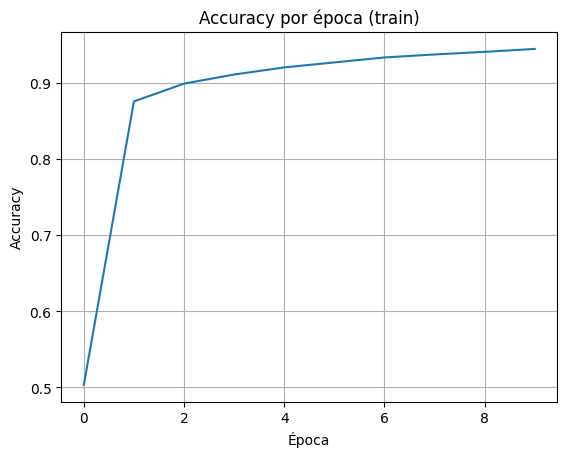

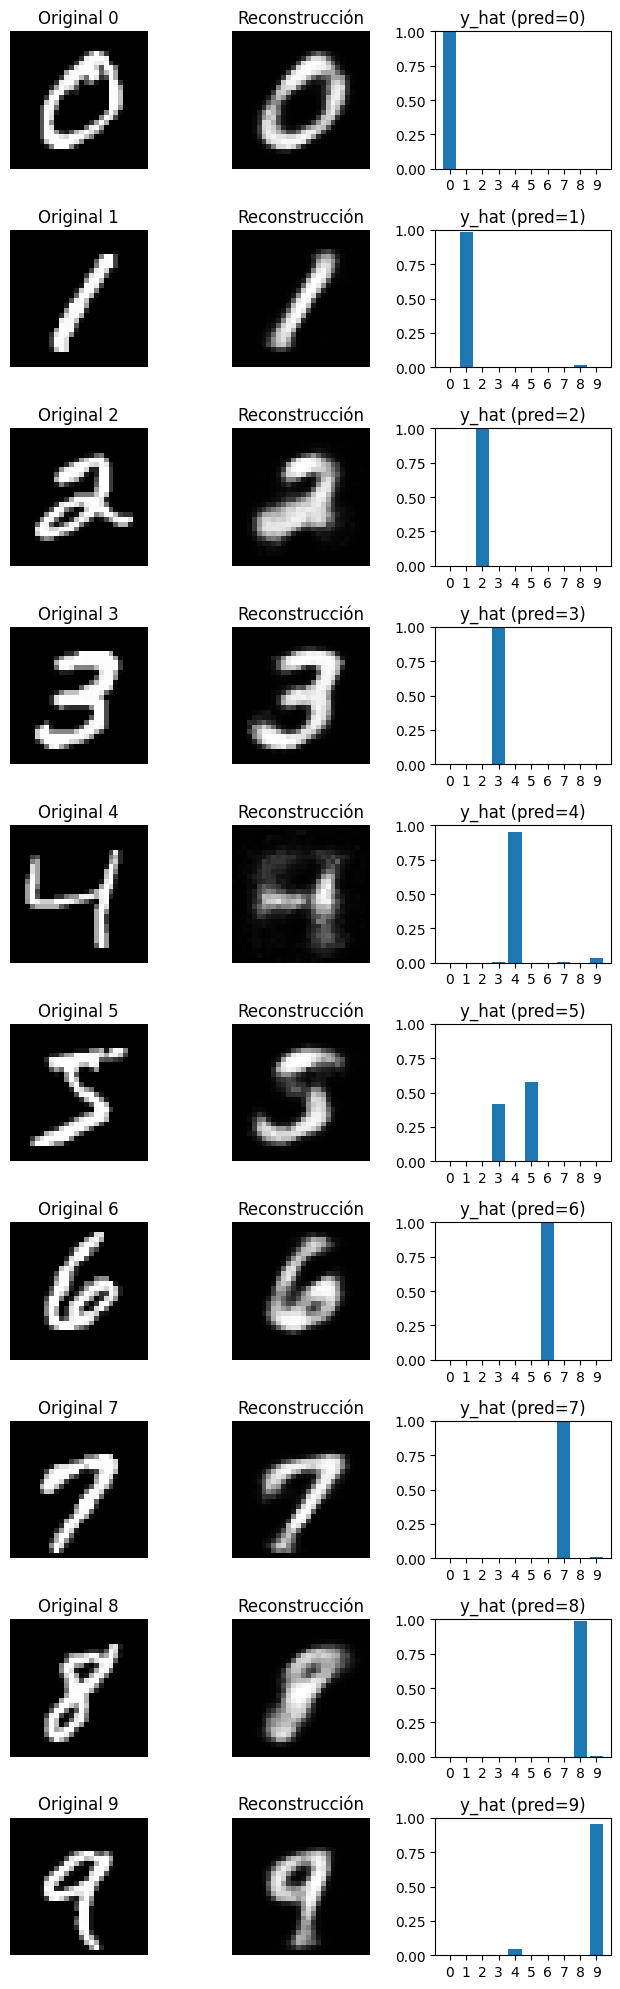


W shape: (10, 16)
b shape: (10,)


In [1]:
# -*- coding: utf-8 -*-
"""
Autoencoder MNIST + head softmax( zW + b ) para obtener distribución de probabilidad (10 clases)
Pérdida de clasificación: MSE( one-hot(y), y_hat )
(Opcional) Pérdida de reconstrucción del AE: BCE( x_hat, x )
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------
# Datos MNIST
# -------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

# -------------------------
# Modelo: Autoencoder + clasificador softmax
# -------------------------
class AEWithSoftmaxHead(nn.Module):
    def __init__(self, latent_dim=16, n_classes=10):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()  # salida en [0,1]
        )

        # Head: logits = zW + b ; y_hat = softmax(logits)
        self.classifier = nn.Linear(latent_dim, n_classes)

    def forward(self, x):
        x = x.view(-1, 784)
        z = self.encoder(x)
        x_hat = self.decoder(z)
        logits = self.classifier(z)
        y_hat = F.softmax(logits, dim=1)
        return z, x_hat, logits, y_hat

model = AEWithSoftmaxHead(latent_dim=16, n_classes=10).to(device)

# -------------------------
# Pérdidas y optimizador
# -------------------------
# Reconstrucción (como tu ejemplo)
recon_criterion = nn.BCELoss()

# Clasificación (la que pides): MSE sobre one-hot vs softmax
cls_criterion = nn.MSELoss()

# Peso de la reconstrucción:
# - si quieres "solo" usar la MSE de clasificación, pon LAMBDA_RECON = 0.0
LAMBDA_RECON = 1.0

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

# -------------------------
# Entrenamiento
# -------------------------
epochs = 10

loss_total_hist, loss_recon_hist, loss_cls_hist, acc_hist = [], [], [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_cls = 0.0
    correct = 0
    n = 0

    for images, labels in train_loader:
        images = images.to(device)                  # [B,1,28,28]
        labels = labels.to(device)                  # [B]

        # One-hot: [B,10]
        y = F.one_hot(labels, num_classes=10).float()

        # Forward
        z, x_hat, logits, y_hat = model(images)     # y_hat = softmax

        # Loss clasificación MSE(one-hot, softmax)
        loss_cls = cls_criterion(y_hat, y)

        # Loss reconstrucción BCE(x_hat, x)
        x_flat = images.view(-1, 784)
        loss_recon = recon_criterion(x_hat, x_flat)

        loss = loss_cls + LAMBDA_RECON * loss_recon

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Métricas
        total_loss += loss.item()
        total_recon += loss_recon.item()
        total_cls += loss_cls.item()

        preds = torch.argmax(y_hat, dim=1)
        correct += (preds == labels).sum().item()
        n += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    avg_recon = total_recon / len(train_loader)
    avg_cls = total_cls / len(train_loader)
    acc = correct / n

    loss_total_hist.append(avg_loss)
    loss_recon_hist.append(avg_recon)
    loss_cls_hist.append(avg_cls)
    acc_hist.append(acc)

    print(f"Época [{epoch+1}/{epochs}] | loss={avg_loss:.4f} | cls(MSE)={avg_cls:.4f} | recon(BCE)={avg_recon:.4f} | acc={acc*100:.2f}%")

# -------------------------
# Curvas
# -------------------------
plt.figure()
plt.plot(loss_total_hist, label="Loss total")
plt.plot(loss_cls_hist, label="Loss cls (MSE)")
plt.plot(loss_recon_hist, label=f"Loss recon (BCE)*{LAMBDA_RECON}")
plt.title("Pérdidas por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(acc_hist)
plt.title("Accuracy por época (train)")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# -------------------------
# Visualización: 1 ejemplo por clase (original vs reconstrucción) + y_hat
# -------------------------
model.eval()

# Guardar un ejemplo por clase
examples = {i: None for i in range(10)}
example_labels = {}

for img, label in train_dataset:
    if examples[label] is None:
        examples[label] = img
        example_labels[label] = label
    if all(v is not None for v in examples.values()):
        break

fig, axes = plt.subplots(10, 3, figsize=(6.5, 20))

with torch.no_grad():
    for i in range(10):
        original = examples[i].to(device).view(1, -1)          # [1,784]
        # forward "manual" pasando por el modelo
        z = model.encoder(original)
        recon = model.decoder(z)
        logits = model.classifier(z)
        y_hat = F.softmax(logits, dim=1).cpu().numpy().ravel()

        axes[i, 0].imshow(original.cpu().view(28, 28), cmap='gray')
        axes[i, 0].set_title(f"Original {i}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(recon.cpu().view(28, 28), cmap='gray')
        axes[i, 1].set_title("Reconstrucción")
        axes[i, 1].axis('off')

        pred = int(y_hat.argmax())
        axes[i, 2].bar(range(10), y_hat)
        axes[i, 2].set_title(f"y_hat (pred={pred})")
        axes[i, 2].set_xticks(range(10))
        axes[i, 2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# -------------------------
# (Opcional) Ver W y b del head: softmax(zW + b)
# -------------------------
W = model.classifier.weight.detach().cpu()  # [10, latent_dim]
b = model.classifier.bias.detach().cpu()    # [10]
print("\nW shape:", tuple(W.shape))
print("b shape:", tuple(b.shape))

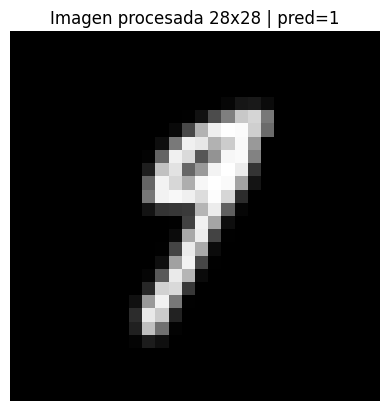

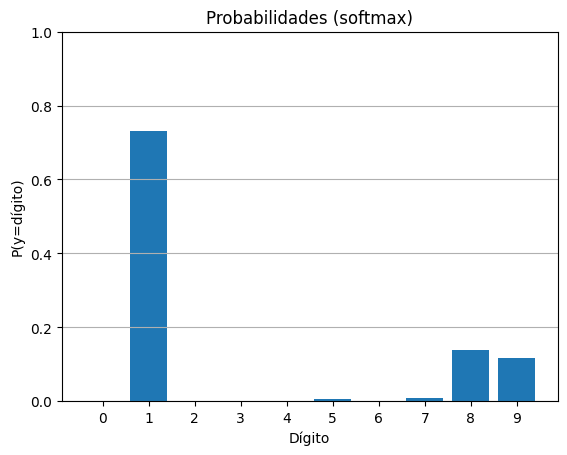

Predicción: 1
Probabilidades: [0.000e+00 7.299e-01 0.000e+00 7.000e-04 1.000e-04 5.700e-03 0.000e+00
 8.800e-03 1.389e-01 1.159e-01]


In [10]:
import torch
import torch.nn.functional as F
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np

def predict_handdrawn_png(
    model,
    image_path: str,
    device=None,
    invert: bool = False,
    show: bool = True,
):
    """
    Carga una imagen (png/jpg), la convierte a formato MNIST (1x28x28 en [0,1]),
    y devuelve la predicción (argmax) + vector de probabilidades (softmax).

    Parámetros
    ----------
    model : tu AEWithSoftmaxHead (o similar) ya entrenado
    image_path : ruta a la imagen
    device : torch.device (si None, intenta inferir)
    invert : si tu dibujo es negro sobre blanco normalmente NO hace falta.
             Si el modelo te predice mal, prueba invert=True.
    show : si True, muestra imagen procesada + histograma de probabilidades.
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    # 1) Cargar imagen y pasar a escala de grises
    img = Image.open(image_path).convert("L")

    # 2) (Opcional) invertir colores
    # MNIST: fondo negro (0), trazo blanco (1)
    # Si tu dibujo es negro sobre blanco, quizás necesites invertir.
    if invert:
        img = ImageOps.invert(img)

    # 3) Redimensionar a 28x28 (misma dimensión MNIST)
    img_28 = img.resize((28, 28), resample=Image.BILINEAR)

    # 4) Normalizar a [0,1] y dar forma (1,1,28,28)
    x = np.array(img_28, dtype=np.float32) / 255.0
    x_t = torch.tensor(x).unsqueeze(0).unsqueeze(0).to(device)  # [1,1,28,28]

    # 5) Forward: obtener y_hat
    with torch.no_grad():
        # tu modelo devuelve: z, x_hat, logits, y_hat
        z, x_hat, logits, y_hat = model(x_t)

    probs = y_hat.squeeze(0).detach().cpu().numpy()  # [10]
    pred = int(np.argmax(probs))

    if show:
        # Imagen procesada (la que realmente "ve" el modelo)
        plt.figure()
        plt.imshow(x, cmap="gray")
        plt.title(f"Imagen procesada 28x28 | pred={pred}")
        plt.axis("off")
        plt.show()

        # Histograma de probabilidades
        plt.figure()
        plt.bar(range(len(probs)), probs)
        plt.xticks(range(len(probs)))
        plt.ylim(0, 1)
        plt.title("Probabilidades (softmax)")
        plt.xlabel("Dígito")
        plt.ylabel("P(y=dígito)")
        plt.grid(True, axis="y")
        plt.show()

    print(f"Predicción: {pred}")
    print("Probabilidades:", np.round(probs, 4))

    return pred, probs, x_t

# USO:
pred, probs, x_t = predict_handdrawn_png(model, "dos.png", invert=False)
# Si te falla mucho porque tu trazo es negro sobre blanco, prueba:
# pred, probs, x_t = predict_handdrawn_png(model, "./mi_dibujo.png", invert=True)